(1690, 2945, 3)


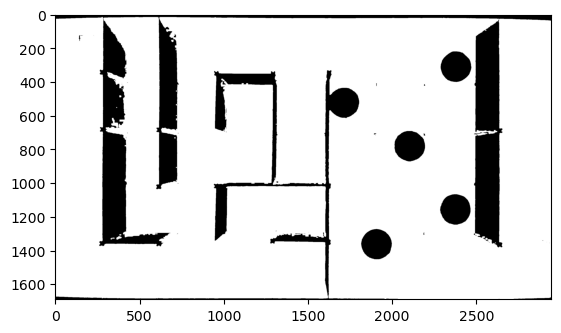

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Open an image
IMAGE_FILE = "obstacle.jpeg"
thresh = 128
maxval = 255

img_maze = cv2.imread(IMAGE_FILE)
img_hsv = cv2.cvtColor(img_maze[260:1950, 480:3425], cv2.COLOR_BGR2HSV)

hsv_mask = cv2.inRange(img_hsv, (4,38,101), (27,255, 255))

_, threshed = cv2.threshold(hsv_mask, thresh, maxval, cv2.THRESH_BINARY)
threshed_3_channel = cv2.cvtColor(threshed, cv2.COLOR_GRAY2BGR)

kernel_size = 3
kernel = np.ones((kernel_size, kernel_size), np.uint8)
threshed_3_channel = cv2.dilate(threshed_3_channel, kernel, iterations = 2)

print(threshed_3_channel.shape)
pts1 = np.float32()

# plt.figure(figsize = (9,5))
plt.imshow(threshed_3_channel)
plt.show()

In [43]:
# Task 2.1 (3 marks):  Complete the graph class

class Node:
    def __init__(self, node_id, x, y):
        self.id = node_id
        self.x = x
        self.y = y
    
    def get_point(self):
        return (self.x,self.y)
    
    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y):
        if node_id not in self.nodes:
            self.nodes[node_id] = Node(node_id, x, y)
            self.edges[node_id] = {}
        pass

    def add_edge(self, node_id1, node_id2, weight):
        if node_id1 in self.nodes and node_id2 in self.nodes:
            self.edges[node_id1][node_id2] = weight
            self.edges[node_id2][node_id1] = weight
        pass

    def remove_edge(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            del self.edges[node_id1][node_id2]
            del self.edges[node_id2][node_id1]
        pass
    
    def get_nodes(self):
        return self.nodes
    
    def get_edge_weight(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            return self.edges[node_id1][node_id2]
        return None 

In [45]:
def path_clear(image, x1, y1, x2, y2):
    line_iter = np.linspace(0, 1, int(np.sqrt((x2 - x1)**2 + (y2 - y1)**2)))
    for t in line_iter:
        x = int(x1 * (1 - t) + x2 * t)
        y = int(y1 * (1 - t) + y2 * t)  
        if (image[y, x][0] == 0 and image[y, x][1] == 0 and image[y, x][2] == 0) or (image[y, x][0] == 255 and image[y, x][1] == 0 and image[y, x][2] == 0):  # Black or red
            return False
    return True

50


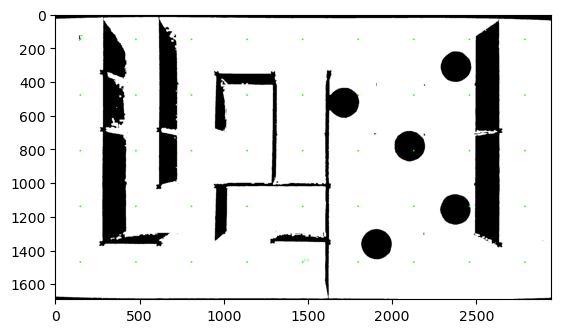

In [114]:
bfs_image = threshed_3_channel.copy()
bfs_graph = Graph()

node_id = 0
size_of_node_grid = 10

# Initialize the size of the array
img_width = bfs_image.shape[1]
img_height = bfs_image.shape[0]

grid_spacing_x = 330
grid_spacing_y = 330

# Get nodes
dictionary = bfs_graph.get_nodes()
height = 5
width = 9
border = 150

# Generate nodes
for i in range(height):
    for j in range(width + 1):        
        x = border + j * grid_spacing_y
        y = border + i * grid_spacing_x
        bfs_graph.add_node(node_id, x, y)
        node_id += 1

print(node_id)
# # Generate edges
# Horizontal
for i in range(0, node_id, height):
    for j in range(width + 1):
        node_id1 = i + j
        node_id2 = node_id1 + 1
        x1, y1 = dictionary[node_id1].get_point()
        x2, y2 = dictionary[node_id2].get_point()
        if path_clear(bfs_image, x1, y1, x2, y2):
            bfs_graph.add_edge(node_id1, node_id2, 1)

# Vertical
for i in range(width + 1):
    for j in range(0, 90, height):
        node_id1 = i + j
        node_id2 = node_id1 + width + 1
        x1, y1 = dictionary[node_id1].get_point()
        x2, y2 = dictionary[node_id2].get_point()
        if path_clear(bfs_image, x1, y1, x2, y2):
            bfs_graph.add_edge(node_id1, node_id2, 1)
    
# Font settings
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
color = (0, 255, 0)  # White color
thickness = 1

# Display nodes            
for node_id in dictionary:
    x, y = dictionary[node_id].get_point()
    cv2.circle(bfs_image, (x, y), 5, (0, 255, 0), -1)
    if node_id == 0 or node_id == 44:
        cv2.putText(bfs_image, str(node_id), (x, y), font, font_scale, color, thickness, cv2.LINE_AA)  

# Display edges
# for node_id1 in dictionary:
#     for node_id2 in dictionary:
#         if bfs_graph.get_edge_weight(node_id1, node_id2) != None:
#             x1, y1 = dictionary[node_id1].get_point()
#             x2, y2 = dictionary[node_id2].get_point()
#             cv2.line(bfs_image, (x1, y1), (x2, y2), (0, 255, 0), 4)

# Display Resulting Image
plt.imshow(bfs_image)
plt.show()